In [1]:
!pip install -q -r requirements.txt

In [2]:
!nvidia-smi

Sat Oct  3 09:37:53 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
!python train_bert.py

Train size: 230  |  Val size: 58
Loading weights: 100% 199/199 [00:00<00:00, 5071.80it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because miss

In [5]:
!ls saved_model

config.json  model.safetensors	tokenizer_config.json  tokenizer.json


In [9]:
!python predict.py

Loading weights: 100% 201/201 [00:00<00:00, 5433.28it/s]
=== Batch predictions on sample texts ===
Text: The professor explained everything clearly and the course was very engaging.
Predicted: Positive  (confidence: 0.75)

Text: The lab sessions were a complete waste of time, badly organized.
Predicted: Negative  (confidence: 0.63)

Text: The assignments were okay, nothing special.
Predicted: Neutral  (confidence: 0.73)

=== Type your own feedback (or 'quit' to exit) ===

Feedback: Not satisfied with the professor, it felt rushed and incomplete.
Predicted: Negative  (confidence: 0.79)

Feedback: I am not happy
Predicted: Negative  (confidence: 0.44)

Feedback: He is a very good student
Predicted: Negative  (confidence: 0.43)

Feedback: The exam pattern was excellent and improved my understanding a lot.
Predicted: Positive  (confidence: 0.74)

Feedback: quit


In [10]:
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Load dataset
df = pd.read_csv("student_feedback.csv")

label_map = {
    "Negative": 0,
    "Neutral": 1,
    "Positive": 2
}

df["label_id"] = df["label"].map(label_map)

# Same split used during training
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label_id"],
    random_state=42
)

# Load trained model
model_path = "./saved_model"

tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

predictions = []
actual = []

for _, row in val_df.iterrows():

    inputs = tokenizer(
        row["feedback_text"],
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=64
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    pred = torch.argmax(outputs.logits, dim=1).item()

    predictions.append(pred)
    actual.append(row["label_id"])

print("Accuracy :", accuracy_score(actual, predictions))
print("Precision:", precision_score(actual, predictions, average="weighted"))
print("Recall   :", recall_score(actual, predictions, average="weighted"))
print("F1 Score :", f1_score(actual, predictions, average="weighted"))

print("\nClassification Report:")
print(classification_report(
    actual,
    predictions,
    target_names=["Negative", "Neutral", "Positive"]
))

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0

Classification Report:
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        19
     Neutral       1.00      1.00      1.00        19
    Positive       1.00      1.00      1.00        20

    accuracy                           1.00        58
   macro avg       1.00      1.00      1.00        58
weighted avg       1.00      1.00      1.00        58



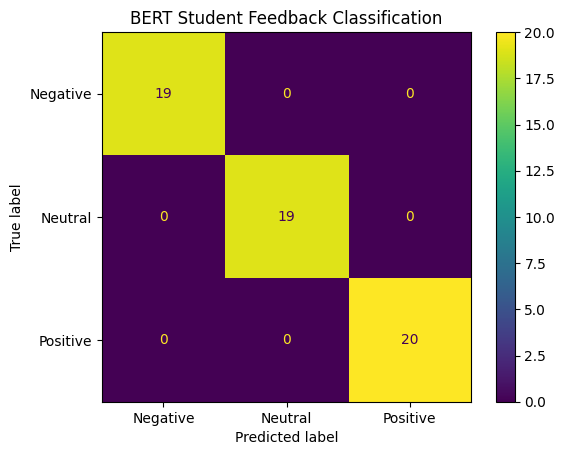

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(actual, predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Neutral", "Positive"]
)

disp.plot()
plt.title("BERT Student Feedback Classification")
plt.show()